In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import minkowski



In [17]:

# ============================================================
# LOAD DATA
# ============================================================

FILE_PATH = r"C:\Users\Siddharth\Downloads\Lab Session Data.xlsx"
SHEET_NAME = "marketing_campaign"


def load_data(file_path, sheet_name):
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    return df


df = load_data(FILE_PATH, SHEET_NAME)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())



Dataset shape: (2240, 29)

First 5 rows:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

           Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0  2012-04-09 00:00:00       58       635  ...                  7   
1  2014-08-03 00:00:00       38        11  ...                  5   
2           21-08-2013       26       426  ...                  4   
3  2014-10-02 00:00:00       26        11  ...                  6   
4           19-01-2014       94       173  ...                  5   

   AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  \


In [18]:

# ============================================================
# A1 - CLASSIFY FEATURES
# ============================================================

def classify_features(df):

    nominal = [
        "ID",
        "Marital_Status",
        "AcceptedCmp1",
        "AcceptedCmp2",
        "AcceptedCmp3",
        "AcceptedCmp4",
        "AcceptedCmp5",
        "Complain",
        "Response"
    ]

    ordinal = [
        "Education"
    ]

    interval = [
        "Year_Birth",
        "Dt_Customer"
    ]

    ratio = [
        "Income",
        "Kidhome",
        "Teenhome",
        "Recency",
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds",
        "NumDealsPurchases",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
        "NumWebVisitsMonth",
        "Z_CostContact",
        "Z_Revenue"
    ]

    # Keep only columns that actually exist
    nominal = [col for col in nominal if col in df.columns]
    ordinal = [col for col in ordinal if col in df.columns]
    interval = [col for col in interval if col in df.columns]
    ratio = [col for col in ratio if col in df.columns]

    return {
        "Nominal": nominal,
        "Ordinal": ordinal,
        "Interval": interval,
        "Ratio": ratio
    }


def display_feature_classification(classification):

    print("\n" + "=" * 60)
    print("A1 - FEATURE CLASSIFICATION")
    print("=" * 60)

    for category, columns in classification.items():

        print(f"\n{category} Features:")

        for col in columns:
            print("  ", col)


feature_types = classify_features(df)

display_feature_classification(feature_types)




A1 - FEATURE CLASSIFICATION

Nominal Features:
   ID
   Marital_Status
   AcceptedCmp1
   AcceptedCmp2
   AcceptedCmp3
   AcceptedCmp4
   AcceptedCmp5
   Complain
   Response

Ordinal Features:
   Education

Interval Features:
   Year_Birth
   Dt_Customer

Ratio Features:
   Income
   Kidhome
   Teenhome
   Recency
   MntWines
   MntFruits
   MntMeatProducts
   MntFishProducts
   MntSweetProducts
   MntGoldProds
   NumDealsPurchases
   NumWebPurchases
   NumCatalogPurchases
   NumStorePurchases
   NumWebVisitsMonth
   Z_CostContact
   Z_Revenue


In [19]:

# ============================================================
# A2 - LABEL ENCODING
# ============================================================

def label_encode_column(df, column, mapping):

    df = df.copy()

    df[column] = df[column].map(mapping)

    return df


def label_encode(df, column_mappings):

    df = df.copy()

    for column, mapping in column_mappings.items():

        df[column] = df[column].map(mapping)

    return df


# Education has a natural order
education_mapping = {
    "Basic": 0,
    "2n Cycle": 1,
    "Graduation": 2,
    "Master": 3,
    "PhD": 4
}


# ============================================================
# A2 - ONE-HOT ENCODING
# ============================================================

def one_hot_encode_column(df, column):

    df = df.copy()

    categories = sorted(df[column].dropna().unique())

    for category in categories:

        new_column = column + "_" + str(category)

        df[new_column] = (
            df[column] == category
        ).astype(int)

    df.drop(column, axis=1, inplace=True)

    return df


def one_hot_encode(df, columns):

    df = df.copy()

    for column in columns:

        df = one_hot_encode_column(df, column)

    return df



In [20]:

# ============================================================
# A3 - ENCODE CATEGORICAL FEATURES
# ============================================================

def encode_categorical_features(df, classification):

    encoded_df = df.copy()

    # Label encoding for ordinal features
    ordinal_mappings = {
        "Education": education_mapping
    }

    encoded_df = label_encode(
        encoded_df,
        ordinal_mappings
    )

    # One-hot encode nominal categorical features
    # ID is intentionally excluded because it is an identifier
    nominal_columns = [
        col for col in classification["Nominal"]
        if col != "ID"
    ]

    encoded_df = one_hot_encode(
        encoded_df,
        nominal_columns
    )

    return encoded_df


encoded_df = encode_categorical_features(
    df,
    feature_types
)

print("\n" + "=" * 60)
print("A3 - ENCODED DATASET")
print("=" * 60)

print("Original dimensions :", df.shape)
print("Encoded dimensions  :", encoded_df.shape)

print("\nEncoded dataset:")
print(encoded_df.head())




A3 - ENCODED DATASET
Original dimensions : (2240, 29)
Encoded dimensions  : (2240, 43)

Encoded dataset:
     ID  Year_Birth  Education   Income  Kidhome  Teenhome  \
0  5524        1957          2  58138.0        0         0   
1  2174        1954          2  46344.0        1         1   
2  4141        1965          2  71613.0        0         0   
3  6182        1984          2  26646.0        1         0   
4  5324        1981          4  58293.0        1         0   

           Dt_Customer  Recency  MntWines  MntFruits  ...  AcceptedCmp3_0  \
0  2012-04-09 00:00:00       58       635         88  ...               1   
1  2014-08-03 00:00:00       38        11          1  ...               1   
2           21-08-2013       26       426         49  ...               1   
3  2014-10-02 00:00:00       26        11          4  ...               1   
4           19-01-2014       94       173         43  ...               1   

   AcceptedCmp3_1  AcceptedCmp4_0  AcceptedCmp4_1  Accepte


Numeric data shape for distance calculations:
(2240, 42)

A5 - MINKOWSKI DISTANCE
p =  1 : distance = 14278.0000
p =  2 : distance = 11855.2285
p =  3 : distance = 11796.4264
p =  4 : distance = 11794.1143
p =  5 : distance = 11794.0059
p =  6 : distance = 11794.0003
p =  7 : distance = 11794.0000
p =  8 : distance = 11794.0000
p =  9 : distance = 11794.0000
p = 10 : distance = 11794.0000


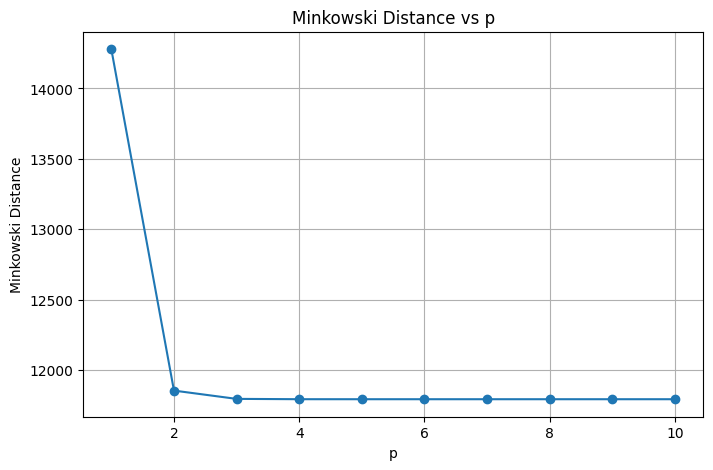

In [21]:

# ============================================================
# PREPARE DATA FOR DISTANCE CALCULATIONS
# ============================================================

def prepare_numeric_data(df, classification):

    data = df.copy()

    # Convert date to numerical representation
    if "Dt_Customer" in data.columns:

        data["Dt_Customer"] = pd.to_datetime(
            data["Dt_Customer"],
            errors="coerce"
        )

        # Convert date to number of days
        data["Dt_Customer"] = (
            data["Dt_Customer"] -
            data["Dt_Customer"].min()
        ).dt.days

    # Apply ordinal encoding
    data = label_encode(
        data,
        {
            "Education": education_mapping
        }
    )

    # One-hot encode nominal categorical columns
    nominal_columns = [
        col for col in classification["Nominal"]
        if col != "ID"
    ]

    data = one_hot_encode(
        data,
        nominal_columns
    )

    # Remove ID because it is only an identifier
    if "ID" in data.columns:
        data.drop("ID", axis=1, inplace=True)

    # Convert everything to numeric
    data = data.apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Fill missing numerical values using median
    data = data.fillna(data.median())

    return data


numeric_data = prepare_numeric_data(
    df,
    feature_types
)

print("\nNumeric data shape for distance calculations:")
print(numeric_data.shape)


# ============================================================
# A4 - GENERALIZED MINKOWSKI DISTANCE
# ============================================================

def minkowski_distance(A, B, p):

    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    if len(A) != len(B):
        raise ValueError(
            "Vectors must have the same dimension."
        )

    if p <= 0:
        raise ValueError(
            "p must be greater than 0."
        )

    total = 0

    for i in range(len(A)):

        total += abs(A[i] - B[i]) ** p

    distance = total ** (1 / p)

    return distance


# ============================================================
# A5 - MINKOWSKI DISTANCE FOR p = 1 TO 10
# ============================================================

def calculate_minkowski_range(A, B, min_p=1, max_p=10):

    results = {}

    for p in range(min_p, max_p + 1):

        results[p] = minkowski_distance(
            A, B, p
        )

    return results


def plot_minkowski_distances(results):

    p_values = list(results.keys())
    distances = list(results.values())

    plt.figure(figsize=(8, 5))

    plt.plot(
        p_values,
        distances,
        marker="o"
    )

    plt.xlabel("p")
    plt.ylabel("Minkowski Distance")
    plt.title("Minkowski Distance vs p")

    plt.grid(True)

    plt.show()


# Select two feature vectors
A = numeric_data.iloc[0].to_numpy()
B = numeric_data.iloc[1].to_numpy()

minkowski_results = calculate_minkowski_range(
    A,
    B
)

print("\n" + "=" * 60)
print("A5 - MINKOWSKI DISTANCE")
print("=" * 60)

for p, distance in minkowski_results.items():

    print(
        f"p = {p:2d} : distance = {distance:.4f}"
    )

plot_minkowski_distances(
    minkowski_results
)



In [22]:

# ============================================================
# A6 - COMPARE WITH SCIPY
# ============================================================

def compare_with_scipy(A, B, p):

    my_result = minkowski_distance(
        A,
        B,
        p
    )

    scipy_result = minkowski(
        A,
        B,
        p
    )

    difference = abs(
        my_result - scipy_result
    )

    return my_result, scipy_result, difference


print("\n" + "=" * 60)
print("A6 - COMPARISON WITH SCIPY")
print("=" * 60)

for p in range(1, 11):

    my_result, scipy_result, difference = (
        compare_with_scipy(A, B, p)
    )

    print(f"\np = {p}")

    print(
        "My function :",
        my_result
    )

    print(
        "SciPy       :",
        scipy_result
    )

    print(
        "Difference  :",
        difference
    )


# ============================================================
# A7 - DOT PRODUCT
# ============================================================

def my_dot(A, B):

    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    if len(A) != len(B):
        raise ValueError(
            "Vectors must have the same dimension."
        )

    total = 0

    for i in range(len(A)):

        total += A[i] * B[i]

    return total




A6 - COMPARISON WITH SCIPY

p = 1
My function : 14278.0
SciPy       : 14278.0
Difference  : 0.0

p = 2
My function : 11855.228466798942
SciPy       : 11855.228466798942
Difference  : 0.0

p = 3
My function : 11796.426369328821
SciPy       : 11796.426369328821
Difference  : 0.0

p = 4
My function : 11794.114273936842
SciPy       : 11794.114273936842
Difference  : 0.0

p = 5
My function : 11794.005933743883
SciPy       : 11794.005933743883
Difference  : 0.0

p = 6
My function : 11794.000329017228
SciPy       : 11794.000329017228
Difference  : 0.0

p = 7
My function : 11794.00001913
SciPy       : 11794.00001913
Difference  : 0.0

p = 8
My function : 11794.000001152343
SciPy       : 11794.000001152343
Difference  : 0.0

p = 9
My function : 11794.000000071297
SciPy       : 11794.000000071297
Difference  : 0.0

p = 10
My function : 11794.00000000451
SciPy       : 11794.00000000451
Difference  : 0.0


In [23]:

# ============================================================
# A7 - EUCLIDEAN NORM
# ============================================================

def my_euclidean_norm(A):

    A = np.asarray(A, dtype=float)

    total = 0

    for x in A:

        total += x ** 2

    return total ** 0.5


print("\n" + "=" * 60)
print("A7 - DOT PRODUCT AND EUCLIDEAN NORM")
print("=" * 60)

my_dot_result = my_dot(A, B)
numpy_dot_result = np.dot(A, B)

my_norm_A = my_euclidean_norm(A)
numpy_norm_A = np.linalg.norm(A)

my_norm_B = my_euclidean_norm(B)
numpy_norm_B = np.linalg.norm(B)

print("\nDot Product")
print("My function :", my_dot_result)
print("NumPy       :", numpy_dot_result)

print("\nNorm of A")
print("My function :", my_norm_A)
print("NumPy       :", numpy_norm_A)

print("\nNorm of B")
print("My function :", my_norm_B)
print("NumPy       :", numpy_norm_B)




A7 - DOT PRODUCT AND EUCLIDEAN NORM

Dot Product
My function : 2698271467.0
NumPy       : 2698271467.0

Norm of A
My function : 58177.515055216994
NumPy       : 58177.515055216994

Norm of B
My function : 46394.67769044203
NumPy       : 46394.67769044203


In [24]:

# ============================================================
# A8 - MEAN
# ============================================================

def my_mean(data):

    data = np.asarray(data, dtype=float)

    total = 0

    for value in data:

        total += value

    return total / len(data)


# ============================================================
# A8 - VARIANCE
# ============================================================

def my_variance(data):

    data = np.asarray(data, dtype=float)

    mean = my_mean(data)

    total = 0

    for value in data:

        total += (value - mean) ** 2

    return total / len(data)


# ============================================================
# A8 - STANDARD DEVIATION
# ============================================================

def my_std(data):

    variance = my_variance(data)

    return variance ** 0.5


# ============================================================
# A8 - CALCULATE STATISTICS FOR MATRIX
# ============================================================

def calculate_statistics_matrix(data):

    data = np.asarray(data, dtype=float)

    means = []
    variances = []
    stds = []

    for column in range(data.shape[1]):

        column_data = data[:, column]

        means.append(
            my_mean(column_data)
        )

        variances.append(
            my_variance(column_data)
        )

        stds.append(
            my_std(column_data)
        )

    return (
        np.array(means),
        np.array(variances),
        np.array(stds)
    )


means, variances, stds = calculate_statistics_matrix(
    numeric_data.to_numpy()
)

print("\n" + "=" * 60)
print("A8 - USER-DEFINED STATISTICS")
print("=" * 60)

print("\nMean vector:")
print(means)

print("\nVariance vector:")
print(variances)

print("\nStandard deviation vector:")
print(stds)




A8 - USER-DEFINED STATISTICS

Mean vector:
[1.96880580e+03 2.46026786e+00 5.22379754e+04 4.44196429e-01
 5.06250000e-01 5.50956696e+02 4.91093750e+01 3.03935714e+02
 2.63022321e+01 1.66950000e+02 3.75254464e+01 2.70629464e+01
 4.40218750e+01 2.32500000e+00 4.08482143e+00 2.66205357e+00
 5.79017857e+00 5.31651786e+00 3.00000000e+00 1.10000000e+01
 8.92857143e-04 1.33928571e-03 1.03571429e-01 3.85714286e-01
 2.14285714e-01 2.58928571e-01 3.43750000e-02 8.92857143e-04
 9.35714286e-01 6.42857143e-02 9.86607143e-01 1.33928571e-02
 9.27232143e-01 7.27678571e-02 9.25446429e-01 7.45535714e-02
 9.27232143e-01 7.27678571e-02 9.90625000e-01 9.37500000e-03
 8.50892857e-01 1.49107143e-01]

Variance vector:
[1.43553806e+02 1.00824279e+00 6.26619369e+08 2.89743104e-01
 2.96389509e-01 5.39066468e+04 8.38449198e+02 1.13247225e+05
 1.58121982e+03 5.09246850e+04 2.98299310e+03 1.70331881e+03
 2.72022675e+03 3.73187500e+00 7.71780533e+00 8.54070293e+00
 1.05640107e+01 5.88597716e+00 0.00000000e+00 0.0000

In [25]:

# ============================================================
# A9 - COMPARE WITH NUMPY
# ============================================================

def compare_statistics_with_numpy(data):

    data = np.asarray(data, dtype=float)

    my_means, my_variances, my_stds = (
        calculate_statistics_matrix(data)
    )

    numpy_means = np.mean(
        data,
        axis=0
    )

    numpy_variances = np.var(
        data,
        axis=0
    )

    numpy_stds = np.std(
        data,
        axis=0
    )

    return (
        my_means,
        numpy_means,
        my_variances,
        numpy_variances,
        my_stds,
        numpy_stds
    )


(
    my_means,
    numpy_means,
    my_variances,
    numpy_variances,
    my_stds,
    numpy_stds
) = compare_statistics_with_numpy(
    numeric_data.to_numpy()
)


print("\n" + "=" * 60)
print("A9 - COMPARISON WITH NUMPY")
print("=" * 60)

print(
    "\nMean vectors equal:",
    np.allclose(my_means, numpy_means)
)

print(
    "Variance vectors equal:",
    np.allclose(
        my_variances,
        numpy_variances
    )
)

print(
    "Standard deviation vectors equal:",
    np.allclose(
        my_stds,
        numpy_stds
    )
)




A9 - COMPARISON WITH NUMPY

Mean vectors equal: True
Variance vectors equal: True
Standard deviation vectors equal: True



A10 - HISTOGRAM

Histogram counts:
[1678  554    7    0    0    0    0    0    0    1]

Bin edges:
[  1730.   68223.6 134717.2 201210.8 267704.4 334198.  400691.6 467185.2
 533678.8 600172.4 666666. ]

Mean = 52237.97544642857
Variance = 626619369.4507393


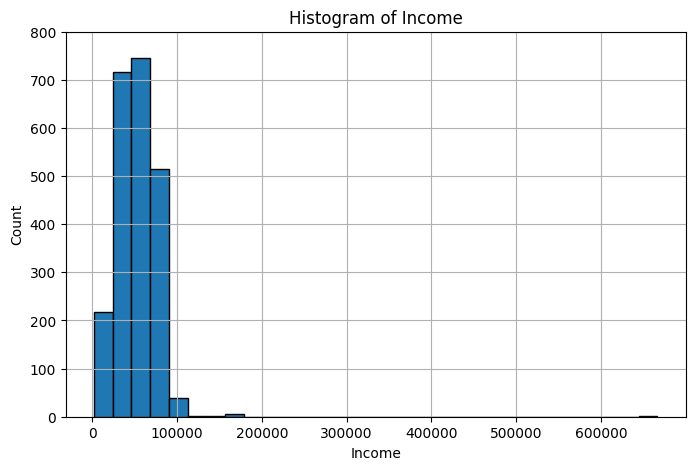

In [41]:

# ============================================================
# A10 - HISTOGRAM
# ============================================================

def generate_histogram_data(data):
    histogram, bin_edges = np.histogram(data)
    return histogram, bin_edges


def plot_histogram(data, feature_name):
    plt.figure(figsize=(8, 5))

    plt.hist(
        data,
        bins=30,
        edgecolor="black"
    )

    plt.xlabel(feature_name)
    plt.ylabel("Count")
    plt.title("Histogram of " + feature_name)

    plt.yticks(
        np.arange(0, plt.ylim()[1] + 100, 100)
    )

    plt.grid(True)
    plt.show()


histogram_feature = "Income"

histogram_data = numeric_data[
    histogram_feature
].to_numpy()

hist_counts, bin_edges = generate_histogram_data(
    histogram_data
)

print("\n" + "=" * 60)
print("A10 - HISTOGRAM")
print("=" * 60)

print("\nHistogram counts:")
print(hist_counts)

print("\nBin edges:")
print(bin_edges)

print(
    "\nMean =",
    my_mean(histogram_data)
)

print(
    "Variance =",
    my_variance(histogram_data)
)

plot_histogram(
    histogram_data,
    histogram_feature
)


A11 - K-MEANS

Number of clusters: 3
Number of iterations: 26

Final centroids:
Centroid 1: Income = 54280.33, MntWines = 319.23
Centroid 2: Income = 29055.50, MntWines = 34.13
Centroid 3: Income = 79531.76, MntWines = 633.56

Number of points in each cluster:
Cluster 1: 852 points
Cluster 2: 785 points
Cluster 3: 603 points


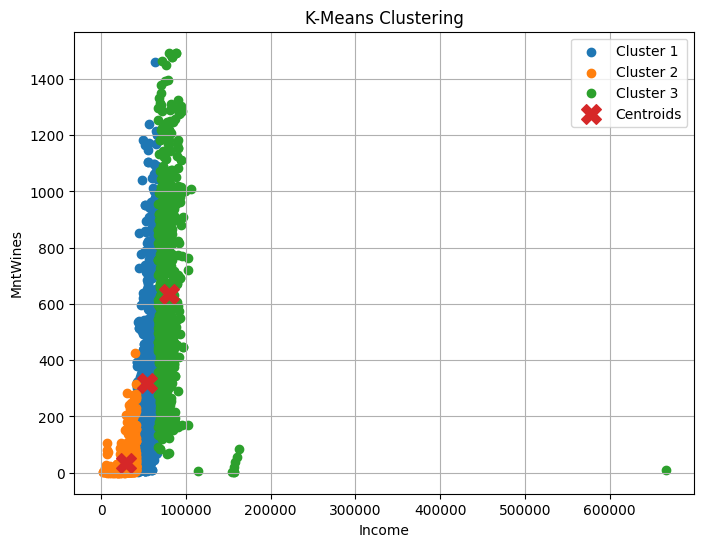

In [38]:
def euclidean_distance(A, B):
    return minkowski_distance(A, B, p=2)


def initialize_centroids(data, k):
    if k <= 0:
        raise ValueError("k must be greater than 0.")
    if k > len(data):
        raise ValueError("k cannot be greater than number of data points.")
    return data[:k].copy()


def assign_clusters(data, centroids):
    labels = []

    for point in data:
        distances = []

        for centroid in centroids:
            distance = euclidean_distance(point, centroid)
            distances.append(distance)

        labels.append(np.argmin(distances))

    return np.array(labels)


def calculate_centroids(data, labels, k, old_centroids):
    new_centroids = []

    for cluster in range(k):
        cluster_points = data[labels == cluster]

        if len(cluster_points) == 0:
            new_centroids.append(old_centroids[cluster])
        else:
            new_centroids.append(
                np.mean(cluster_points, axis=0)
            )

    return np.array(new_centroids)


def centroids_converged(old_centroids, new_centroids, tolerance=1e-6):
    return np.allclose(
        old_centroids,
        new_centroids,
        atol=tolerance
    )


def kmeans(data, k, max_iterations=100):
    data = np.asarray(data, dtype=float)
    centroids = initialize_centroids(data, k)

    for iteration in range(max_iterations):
        labels = assign_clusters(data, centroids)

        new_centroids = calculate_centroids(
            data,
            labels,
            k,
            centroids
        )

        if centroids_converged(
            centroids,
            new_centroids
        ):
            centroids = new_centroids
            break

        centroids = new_centroids

    return labels, centroids, iteration + 1


def plot_kmeans_clusters(data, labels, centroids, feature_names):
    plt.figure(figsize=(8, 6))

    for cluster in range(len(centroids)):
        points = labels == cluster

        plt.scatter(
            data[points, 0],
            data[points, 1],
            label=f"Cluster {cluster + 1}"
        )

    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="X",
        s=200,
        label="Centroids"
    )

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("K-Means Clustering")
    plt.legend()
    plt.grid(True)
    plt.show()


kmeans_features = ["Income", "MntWines"]

kmeans_data = numeric_data[
    kmeans_features
].to_numpy()

K = 3

labels, centroids, iterations = kmeans(
    kmeans_data,
    K
)

print("\n" + "=" * 60)
print("A11 - K-MEANS")
print("=" * 60)

print("\nNumber of clusters:", K)
print("Number of iterations:", iterations)

print("\nFinal centroids:")

for cluster in range(K):
    print(
        f"Centroid {cluster + 1}: "
        f"Income = {centroids[cluster, 0]:.2f}, "
        f"MntWines = {centroids[cluster, 1]:.2f}"
    )

print("\nNumber of points in each cluster:")

for cluster in range(K):
    count = np.sum(labels == cluster)
    print(f"Cluster {cluster + 1}: {count} points")

plot_kmeans_clusters(
    kmeans_data,
    labels,
    centroids,
    kmeans_features
)